# WordCloud and Text Visualization

Text visualization helps communicate frequent words, phrases, sentiment distributions,
and category counts. Word clouds should be treated as exploratory visuals rather than rigorous statistics.

> Run the installation/setup cell first. Some libraries may download language models or datasets the first time.

## Setup

In [1]:
# Uncomment if needed
# %pip install wordcloud matplotlib pandas scikit-learn

import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

## Use Case 1: Create a Word Cloud from Customer Feedback

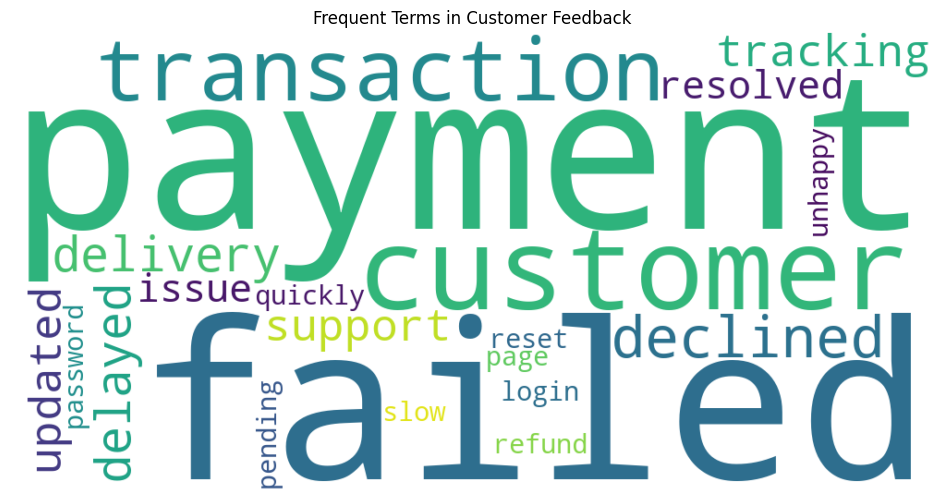

In [2]:
feedback = [
    "payment failed and transaction was declined",
    "delivery was delayed and tracking was not updated",
    "customer support resolved the payment issue quickly",
    "refund is pending and customer is unhappy",
    "login page is slow and password reset failed"
]

combined_text = " ".join(feedback)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=STOPWORDS
).generate(combined_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Frequent Terms in Customer Feedback")
plt.show()

## Use Case 2: Bar Chart of Frequent Meaningful Words

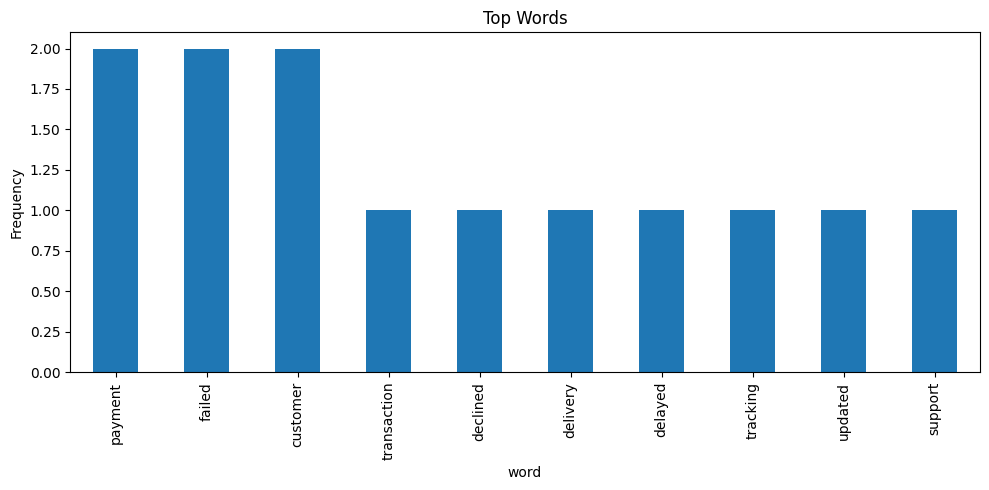

In [3]:
tokens = re.findall(r"[A-Za-z]+", combined_text.lower())
stop_words = set(STOPWORDS)
counts = Counter(word for word in tokens if word not in stop_words)

top_words = pd.DataFrame(counts.most_common(10), columns=["word", "count"])
top_words.plot(kind="bar", x="word", y="count", legend=False, figsize=(10, 5))
plt.title("Top Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Use Case 3: Visualize Category Distribution

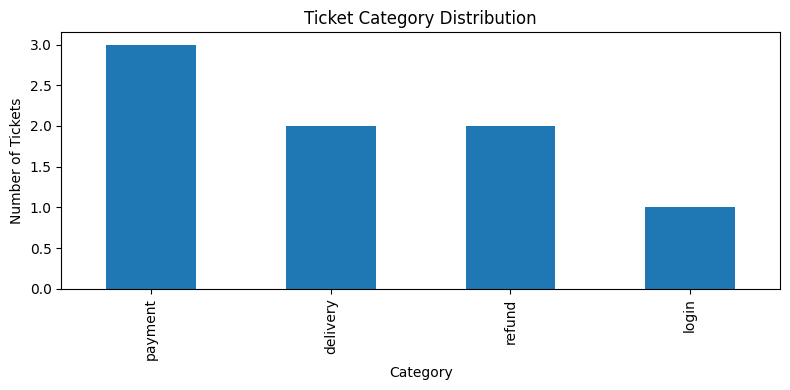

In [4]:
categories = pd.Series([
    "payment", "delivery", "payment", "refund",
    "login", "delivery", "refund", "payment"
])

categories.value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

## Use Case 4: Compare Positive and Negative Word Clouds

<Figure size 1000x800 with 0 Axes>

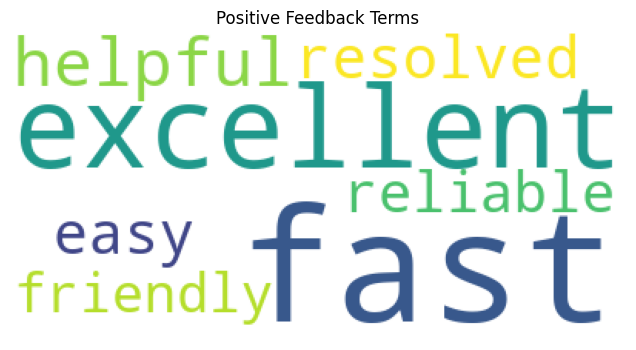

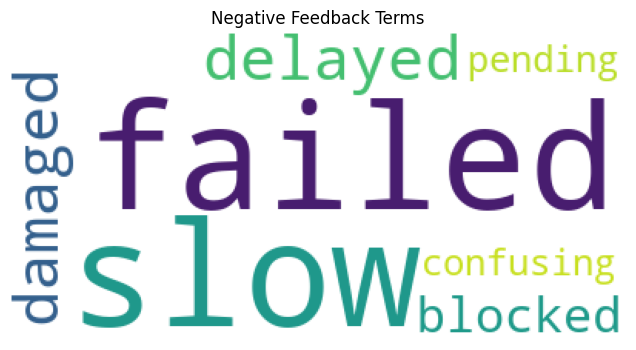

In [5]:
positive = "fast excellent helpful resolved easy reliable friendly"
negative = "slow failed delayed damaged blocked confusing pending"

fig = plt.figure(figsize=(10, 8))

plt.figure(figsize=(10, 4))
plt.imshow(WordCloud(background_color="white").generate(positive))
plt.axis("off")
plt.title("Positive Feedback Terms")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(WordCloud(background_color="white").generate(negative))
plt.axis("off")
plt.title("Negative Feedback Terms")
plt.show()

## Use Case 5: Bigram Frequency Chart

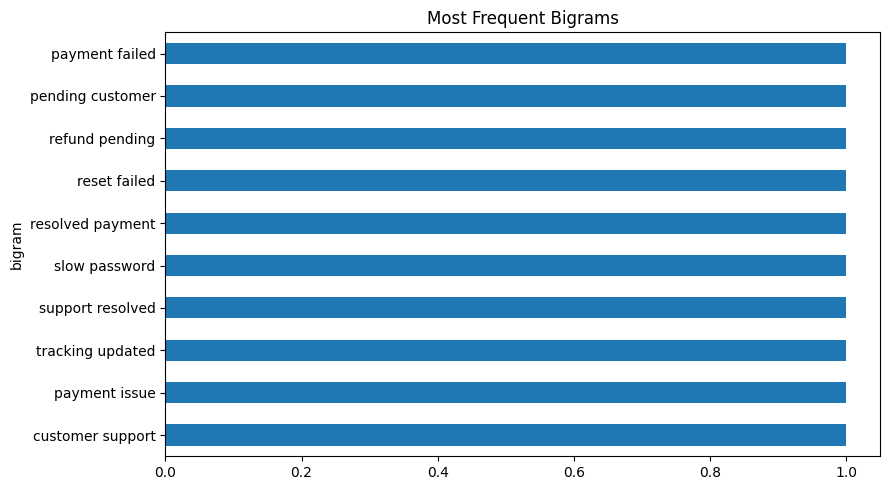

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english")
matrix = vectorizer.fit_transform(feedback)

bigram_counts = matrix.sum(axis=0).A1
bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
}).sort_values("count", ascending=False).head(10)

bigrams.plot(kind="barh", x="bigram", y="count", legend=False, figsize=(9, 5))
plt.title("Most Frequent Bigrams")
plt.tight_layout()
plt.show()

## Use Case 6: Text-Length Distribution

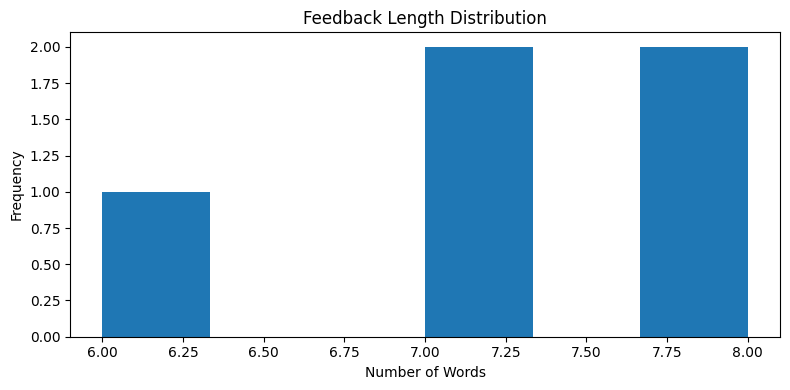

In [7]:
df = pd.DataFrame({"feedback": feedback})
df["word_count"] = df["feedback"].str.split().str.len()

df["word_count"].plot(kind="hist", bins=6, figsize=(8, 4))
plt.title("Feedback Length Distribution")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

## Practice Tasks
1. Create separate word clouds per category.
2. Plot the top complaint bigrams.
3. Compare review length across sentiment labels.